# Data loading & Basic Inspection

In [1]:
import pandas as pd
from IPython.display import display

df = pd.read_excel("drugsCom_raw.xlsx")

print("First 5 rows of the Dataset")
display(df.head())

print("\nShape:", df.shape)

print("\nInformation")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows of the Dataset


,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37



Shape: (161297, 7)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Unnamed: 0   161297 non-null  int64         
 1   drugName     161297 non-null  object        
 2   condition    160398 non-null  object        
 3   review       161297 non-null  object        
 4   rating       161297 non-null  int64         
 5   date         161297 non-null  datetime64[ns]
 6   usefulCount  161297 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 8.6+ MB

Missing values:
Unnamed: 0       0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64


***Filtering the Project Conditions***

In [2]:
df = df[['drugName','condition','review']]

df['condition'] = df['condition'].str.strip()
df['condition'] = df['condition'].str.replace('&#039;', "'", regex=False)

target_conditions = [
    'Depression',
    'High Blood Pressure',
    'Diabetes, Type 2']

df = df[df['condition'].isin(target_conditions)]

# Exploratory Data Analysis (EDA)

## Class Distribution of Target Conditions

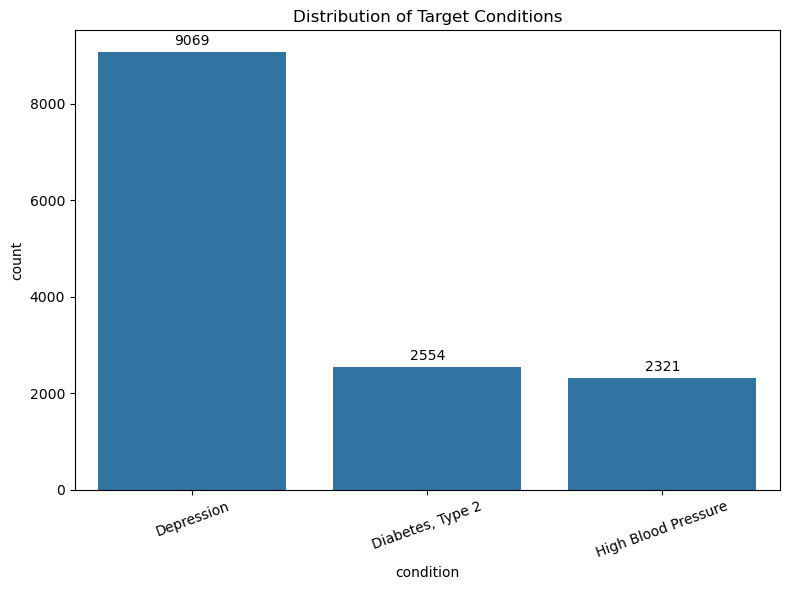

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(8,6))

# Create countplot
ax = sns.countplot(x='condition', data=df)

# Title and axis formatting
plt.title("Distribution of Target Conditions")
plt.xticks(rotation=20)

# Add Numbers on Bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

# Show plot
plt.tight_layout()
plt.show()

***Missing Data***

In [4]:
# Dropping the Null values
df = df.dropna(subset=['review','drugName'])

## Text Cleaning

In [5]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    # remove urls
    text = re.sub(r'http\S+',' ',text)

    # keep only alphabets
    text = re.sub(r'[^a-zA-Z ]',' ',text)

    words = text.split()

    # remove stopwords
    words = [w for w in words if w not in stop_words and len(w)>2]

    # lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)
df['drug_clean'] = df['drugName'].str.lower()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MI\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\MI\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Review Length Analysis

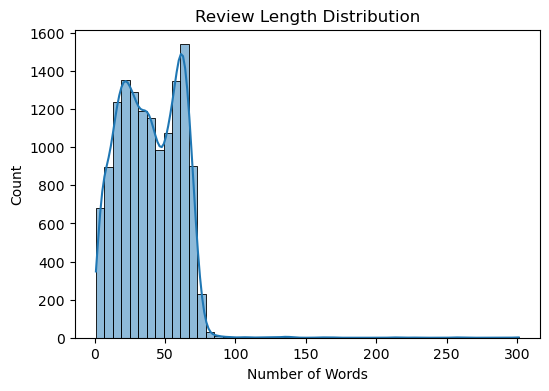

In [6]:
df['review_length'] = df['clean_review'].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))
sns.histplot(df['review_length'], bins=50,kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.show()

***Drug Knowledge Analysis***

In [7]:
drug_condition_counts = df.groupby(['drug_clean','condition']).size().reset_index(name='count')
drug_condition_counts.head(20)

,drug_clean,condition,count
0,abilify,Depression,142
1,acarbose,"Diabetes, Type 2",1
2,acebutolol,High Blood Pressure,2
3,actoplus met,"Diabetes, Type 2",4
4,actos,"Diabetes, Type 2",22
5,afrezza,"Diabetes, Type 2",19
6,albiglutide,"Diabetes, Type 2",9
7,aldactazide,High Blood Pressure,1
8,aldactone,High Blood Pressure,3
9,aldomet,High Blood Pressure,1


In [8]:
# normalize condition column
df['condition_str'] = df['condition'].astype(str).str.lower()

# Depression related conditions
depression_df = df[df['condition_str'].str.contains(
    "depress|depressive|major depressive|mdd|anxiety depression", na=False)]

# Diabetes Type 2 related conditions
diabetes_df = df[df['condition_str'].str.contains(
    "type 2 diabetes|diabetes mellitus type ii|diabetes mellitus type 2|diabetes", na=False)]

# High Blood Pressure related conditions
bp_df = df[df['condition_str'].str.contains(
    "hypertension|high blood pressure|essential hypertension|hypertensive", na=False)]

print("Depression unique drugs:", depression_df['drugName'].nunique())
print("Diabetes Type 2 unique drugs:", diabetes_df['drugName'].nunique())
print("High Blood Pressure unique drugs:", bp_df['drugName'].nunique())

Depression unique drugs: 105
Diabetes Type 2 unique drugs: 89
High Blood Pressure unique drugs: 140


# Feature Engineering

In [9]:
df['combined_text'] = df['drug_clean'] + " " + df['clean_review']

## Label Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['condition'])

## Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['combined_text'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label'])

## TF-IDF Vectorization

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=2)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Model Building

## Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=200)
lr.fit(X_train_vec, y_train)

lr_pred = lr.predict(X_test_vec)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9766941556113302


## Multinomial Naive Bayes

In [14]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

nb_pred = nb.predict(X_test_vec)
nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.9580494801003944


## Linear Support Vector Machine

In [15]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_vec, y_train)

svm_pred = svm.predict(X_test_vec)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.9939046253137325


# Model Evaluation

***Accuracy Comparision***

In [16]:
results = pd.DataFrame({
    'Model':['Logistic Regression','Naive Bayes','SVM'],
    'Accuracy':[lr_acc, nb_acc, svm_acc]})

results

,Model,Accuracy
0,Logistic Regression,0.976694
1,Naive Bayes,0.958049
2,SVM,0.993905


In [17]:
# Selecting the Best Model
model = svm 

## Classification Report

In [18]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_vec)

print(classification_report(y_test,y_pred,target_names=le.classes_))

                     precision    recall  f1-score   support

         Depression       0.99      1.00      1.00      1814
   Diabetes, Type 2       1.00      0.99      0.99       511
High Blood Pressure       0.99      0.98      0.99       464

           accuracy                           0.99      2789
          macro avg       0.99      0.99      0.99      2789
       weighted avg       0.99      0.99      0.99      2789



## Confusion Matrix

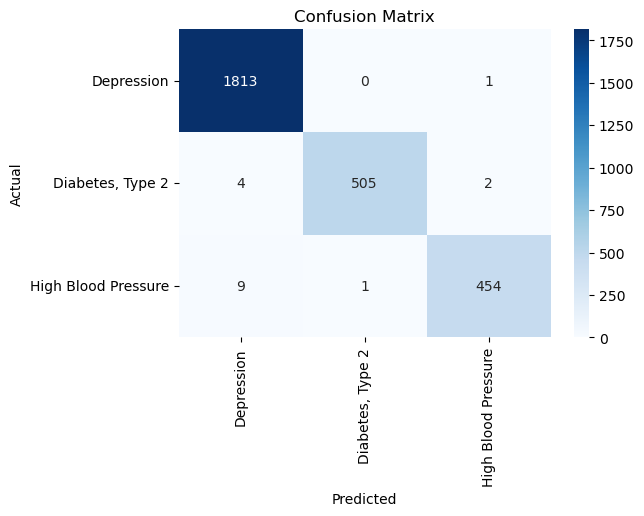

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Deployment

In [20]:
from sklearn.pipeline import Pipeline
import joblib

# Build a complete ML system
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=15000, ngram_range=(1,2), min_df=2)),
    ("classifier", LinearSVC())])

final_pipeline.fit(df['combined_text'], df['condition'])

# Save one single deployment model
joblib.dump(final_pipeline, "final_model.pkl")

print("Final deployment model saved successfully!")

Final deployment model saved successfully!


In [ ]:
import os
os.system("streamlit run app.py")

In [ ]:
import os
import webbrowser
import time

os.system("start streamlit run app.py")

time.sleep(5)

webbrowser.open("http://localhost:8501")